In [ ]:
#Import libaries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import calendar as cal

In [2]:
#Install dataset
csv = 'ecommerce_sales_analytics_5000.csv'
ecomm_data = pd.read_csv(csv)
print('Sucess!')

Sucess!


In [3]:
#Check contents of dataset
print(ecomm_data.describe())
print(ecomm_data.dtypes)
print(ecomm_data.info())
print(ecomm_data.shape)

           order_id  customer_id     quantity   unit_price     discount  \
count   5000.000000  5000.000000  5000.000000  5000.000000  5000.000000   
mean   12500.500000  1505.701200     4.044800   308.418774     0.179984   
std     1443.520003   290.836902     2.020398   169.259369     0.101404   
min    10001.000000  1000.000000     1.000000    15.150000     0.000000   
25%    11250.750000  1253.000000     2.000000   161.895000     0.090000   
50%    12500.500000  1510.000000     4.000000   309.890000     0.180000   
75%    13750.250000  1761.000000     6.000000   455.557500     0.270000   
max    15000.000000  1999.000000     7.000000   599.960000     0.350000   

       delivery_days  customer_rating      revenue  
count    5000.000000      5000.000000  5000.000000  
mean        6.118800         2.973980  1021.955148  
std         3.153264         1.157722   825.584219  
min         1.000000         1.000000    11.210000  
25%         3.000000         2.000000   354.527500  
50%   

In [4]:
#Check for missing values
print(ecomm_data.isna().sum())
print(ecomm_data.isnull().sum())

order_id            0
order_date          0
customer_id         0
product_category    0
region              0
quantity            0
unit_price          0
discount            0
payment_method      0
delivery_days       0
customer_rating     0
revenue             0
dtype: int64
order_id            0
order_date          0
customer_id         0
product_category    0
region              0
quantity            0
unit_price          0
discount            0
payment_method      0
delivery_days       0
customer_rating     0
revenue             0
dtype: int64


In [41]:
#Check for duplicates
print(ecomm_data.duplicated().sum())

0


/tmp/ipykernel_25591/2009012068.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_counts.index, y=region_counts.values, palette='viridis')


Text(0, 0.5, 'Number of Customers')

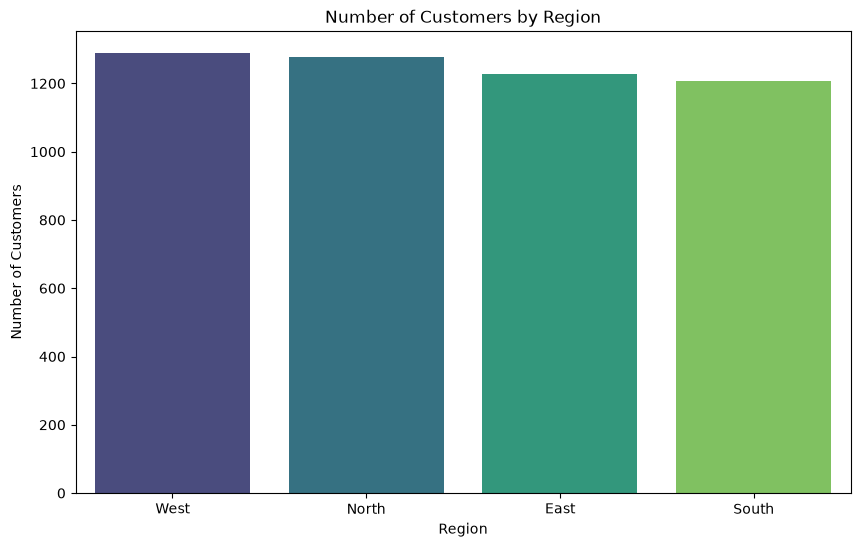

In [14]:
#Looking at customer demographics

#Regions with the highest number of customers
region_counts = ecomm_data['region'].value_counts()
plt.figure(figsize=(10,6))
sns.barplot(x=region_counts.index, y=region_counts.values, palette='viridis')
plt.title('Number of Customers by Region')
plt.xlabel('Region')
plt.ylabel('Number of Customers')


/tmp/ipykernel_25591/1136535054.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=revenue_by_region.index, y=revenue_by_region.values, palette='viridis')


Text(0, 0.5, 'Total Revenue')

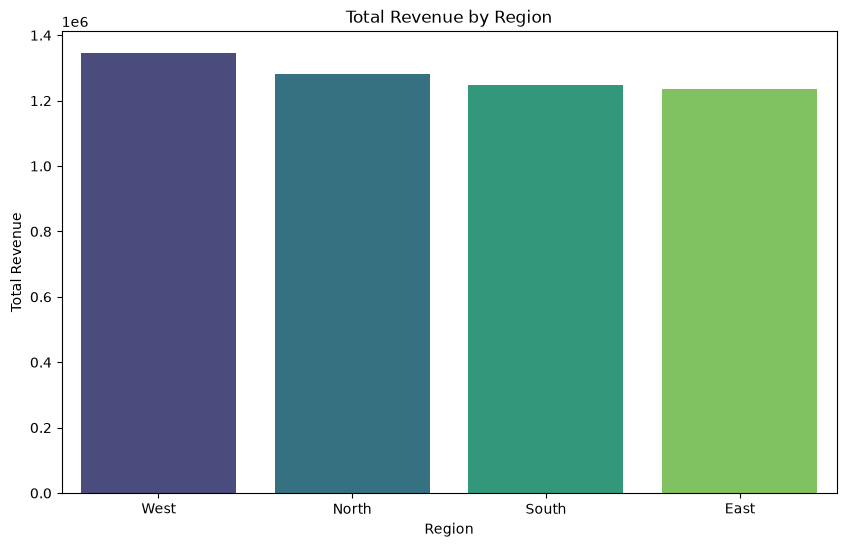

In [15]:
#Looking at revenue by region
revenue_by_region = ecomm_data.groupby('region')['revenue'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=revenue_by_region.index, y=revenue_by_region.values, palette='viridis')
plt.title('Total Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Total Revenue')

Text(0.5, 1.0, 'Product Popularity by Region')

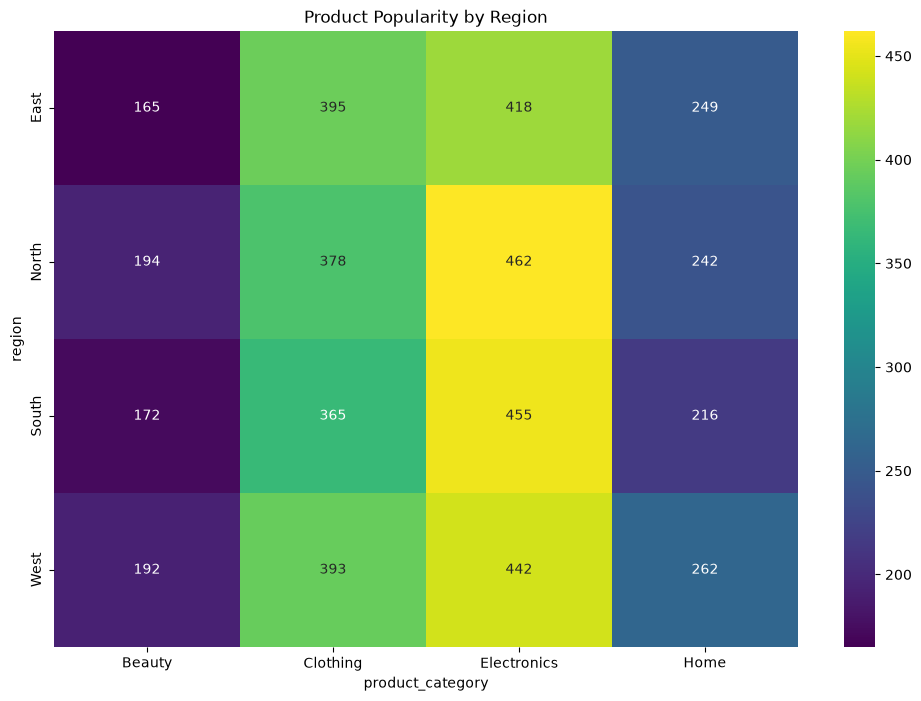

In [16]:
#Looking at What products are most popular in what regions
product_region_counts = ecomm_data.groupby(['region', 'product_category']).size().unstack(fill_value=0)
plt.figure(figsize=(12,8))
sns.heatmap(product_region_counts, annot=True, fmt='d', cmap='viridis')
plt.title('Product Popularity by Region')

/tmp/ipykernel_25591/1807757471.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=delivery_days_by_region.index, y=delivery_days_by_region.values, palette='viridis')


Text(0, 0.5, 'Average Delivery Days (days)')

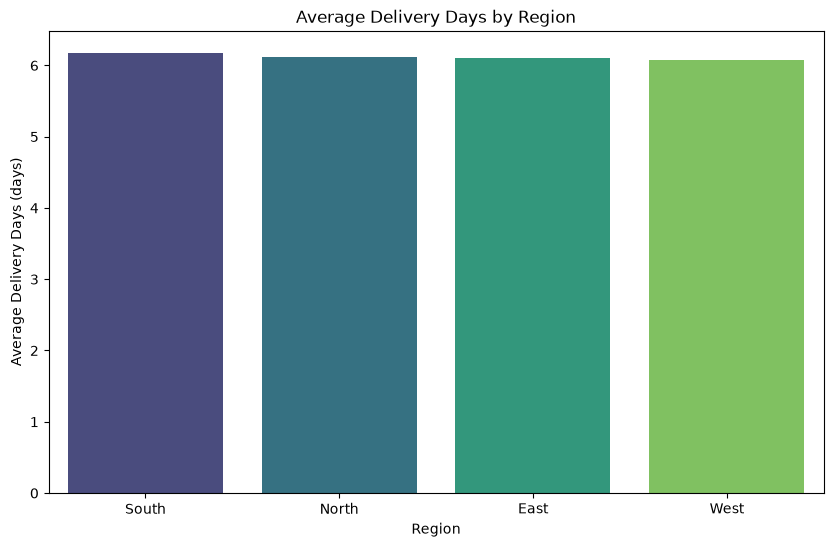

In [18]:
#Looking at how long delivery takes on average by region
delivery_days_by_region = ecomm_data.groupby('region')['delivery_days'].mean().sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=delivery_days_by_region.index, y=delivery_days_by_region.values, palette='viridis')
plt.title('Average Delivery Days by Region')
plt.xlabel('Region')
plt.ylabel('Average Delivery Days (days)')

/tmp/ipykernel_25591/1901893803.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='product_category', y='customer_rating', data=ecomm_data, palette='viridis')


Text(0.5, 1.0, 'Customer Rating by Product Category')

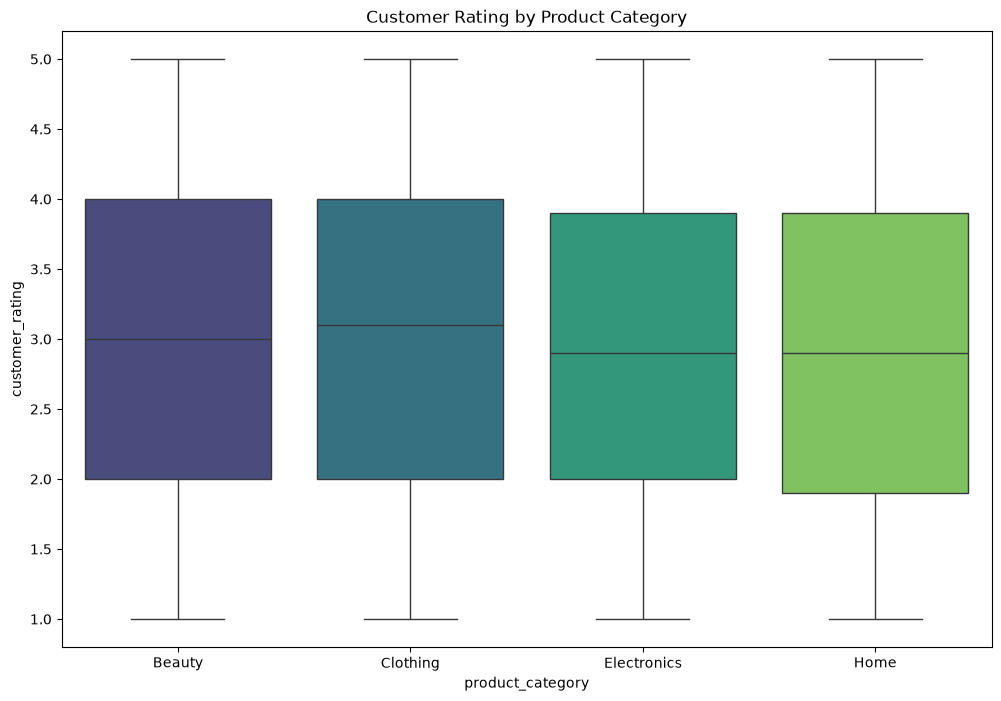

In [21]:
#Customer rating with product category
plt.figure(figsize=(12,8))
sns.boxplot(x='product_category', y='customer_rating', data=ecomm_data, palette='viridis')
plt.title('Customer Rating by Product Category')


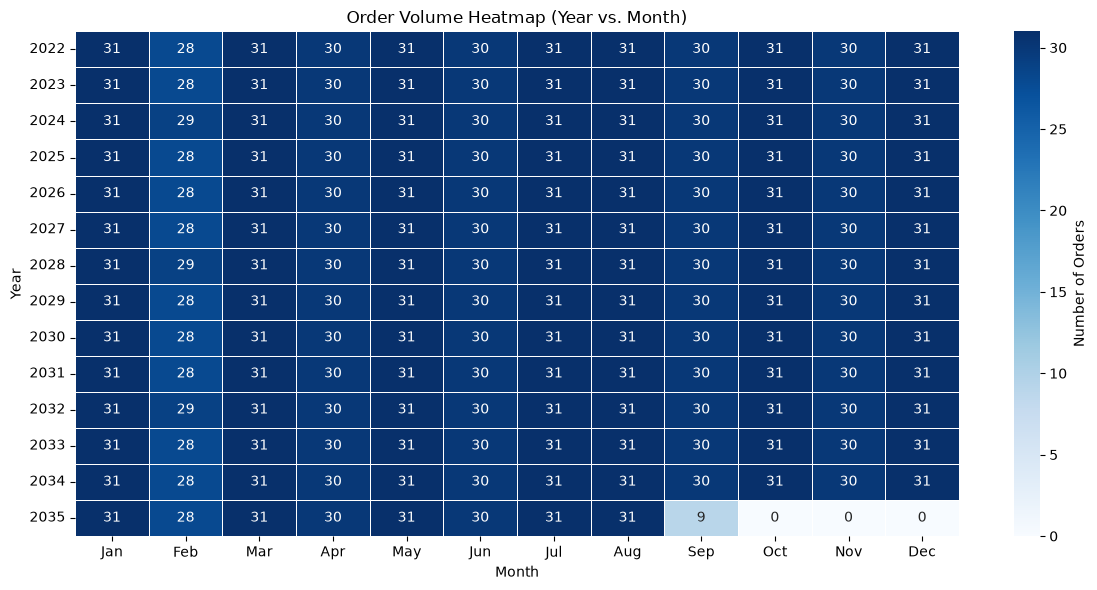

In [ ]:
#Looking for orders made each month of the year

ecomm_data["order_date"] = pd.to_datetime(ecomm_data["order_date"])
ecomm_data["year"] = ecomm_data["order_date"].dt.year
ecomm_data["month_name"] = ecomm_data["order_date"].dt.strftime("%b")

month_order = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec",
]
ecomm_data["month_name"] = pd.Categorical(
    ecomm_data["month_name"], categories=month_order, ordered=True
)
heatmap_data = ecomm_data.pivot_table(
    index="year",
    columns="month_name",
    values="order_date",  # Counts non-null dates
    aggfunc="count",
    observed=False,
)
plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_data,
    cmap="Blues",  
    annot=True, 
    fmt="g", 
    linewidths=0.5, 
    cbar_kws={"label": "Number of Orders"},
)
plt.title("Order Volume Heatmap (Year vs. Month)")
plt.xlabel("Month")
plt.ylabel("Year")
plt.tight_layout()
plt.show()

/tmp/ipykernel_25591/1072879406.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


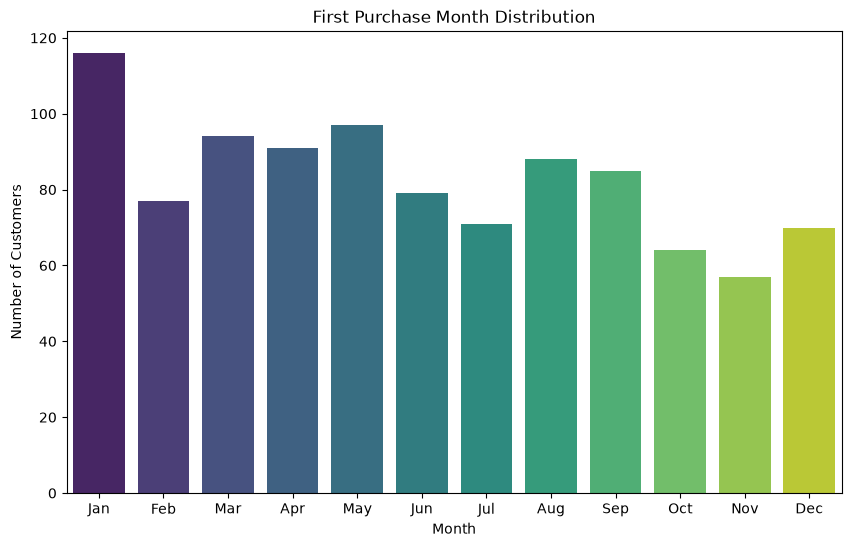

In [39]:
#Month customers made their first purchase
first_purchase_month = ecomm_data.groupby('customer_id')['order_date'].min().dt.strftime('%b')
month_order = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec",
]
first_purchase_month_counts = (first_purchase_month.value_counts().reindex(month_order, fill_value=0)
)

plt.figure(figsize=(10,6))
sns.barplot(
    x=first_purchase_month_counts.index, 
    y=first_purchase_month_counts.values, 
    palette='viridis',
    legend=False,
)
plt.title('First Purchase Month Distribution')
plt.xlabel('Month')
plt.ylabel('Number of Customers')
plt.show()

/tmp/ipykernel_25591/185727762.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


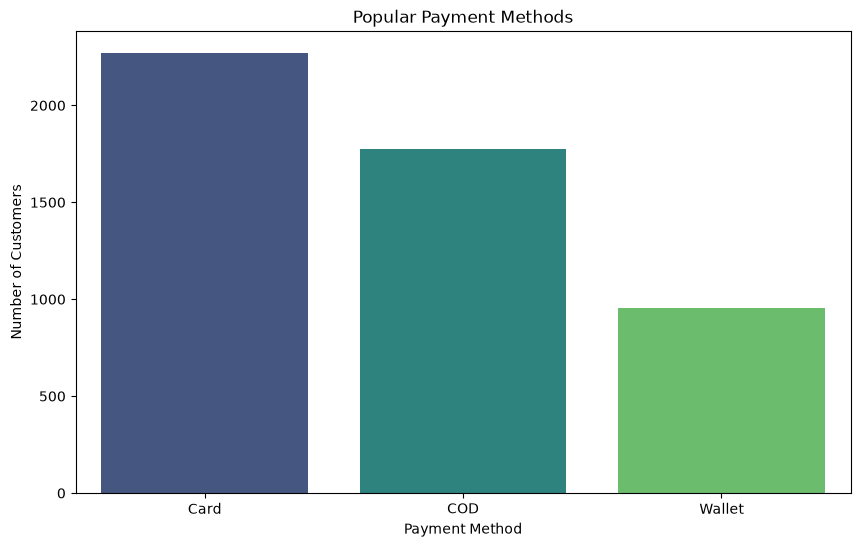

In [40]:
#Popular payment methods by customers 
payment_method_counts = ecomm_data['payment_method'].value_counts()
plt.figure(figsize=(10,6))
sns.barplot(
    x=payment_method_counts.index, 
    y=payment_method_counts.values, 
    palette='viridis',
    legend=False,
)
plt.title('Popular Payment Methods')
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')
plt.show()

Text(0, 0.5, 'Frequency')

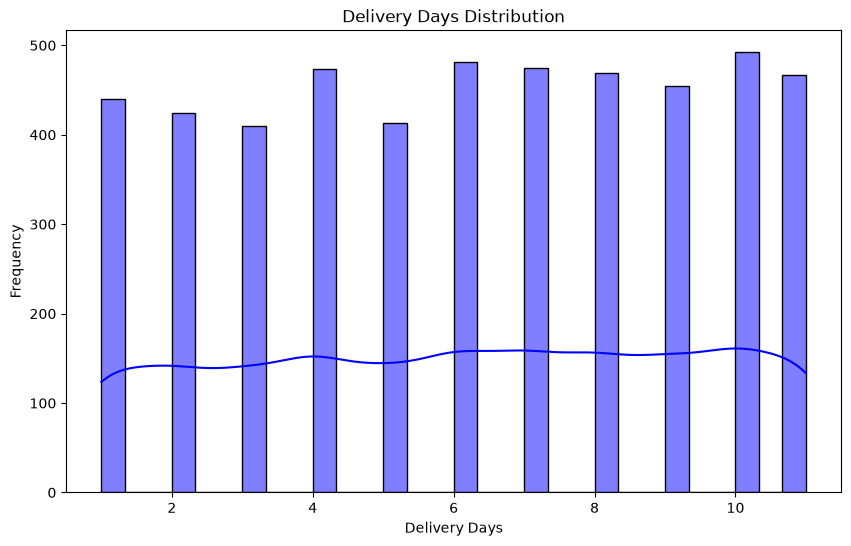

In [42]:
#Delivery days distribution
plt.figure(figsize=(10,6))
sns.histplot(ecomm_data['delivery_days'], bins=30, kde=True, color='blue')
plt.title('Delivery Days Distribution')
plt.xlabel('Delivery Days')
plt.ylabel('Frequency')

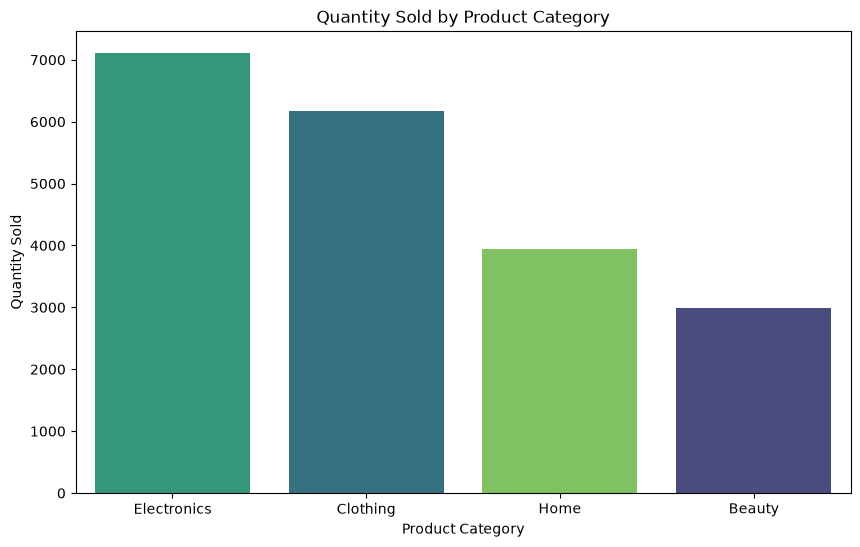

In [47]:
#quantity of each product category sold
#I want the colours to be consistent across both graphs, so I will create a color palette based on the unique product categories and use it for both graphs.
categories = ecomm_data["product_category"].unique()
color_palette = sns.color_palette("viridis", len(categories))
category_colors = dict(zip(categories, color_palette))

quantity_by_category = (
    ecomm_data.groupby("product_category")["quantity"].sum().sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=quantity_by_category.index,
    y=quantity_by_category.values,
    hue=quantity_by_category.index, 
    palette=category_colors,  
    legend=False,
)
plt.title("Quantity Sold by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Quantity Sold")
plt.show()


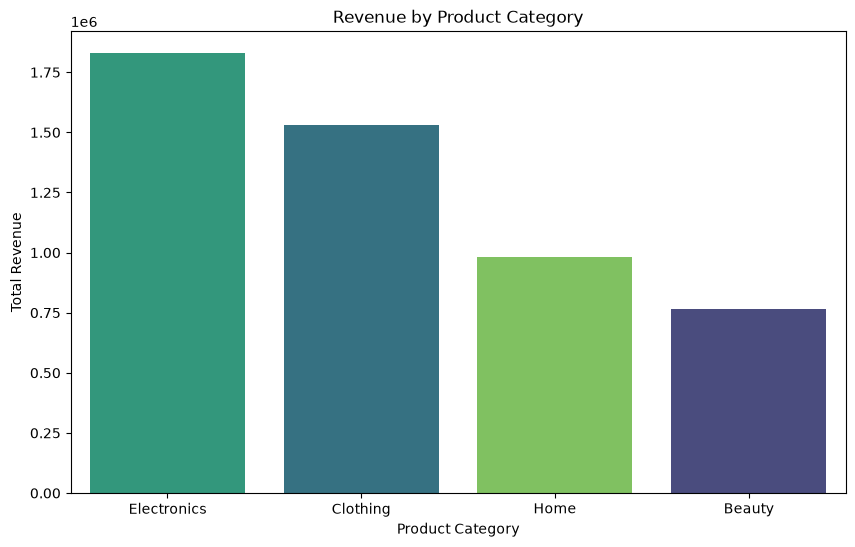

In [48]:
#Revenue by product category
revenue_by_product_category = (
    ecomm_data.groupby("product_category")["revenue"].sum().sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=revenue_by_product_category.index,
    y=revenue_by_product_category.values,
    hue=revenue_by_product_category.index, 
    palette=category_colors,  
    legend=False,
)
plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.show()

5166.608432760364


Text(0, 0.5, 'Revenue ($)')

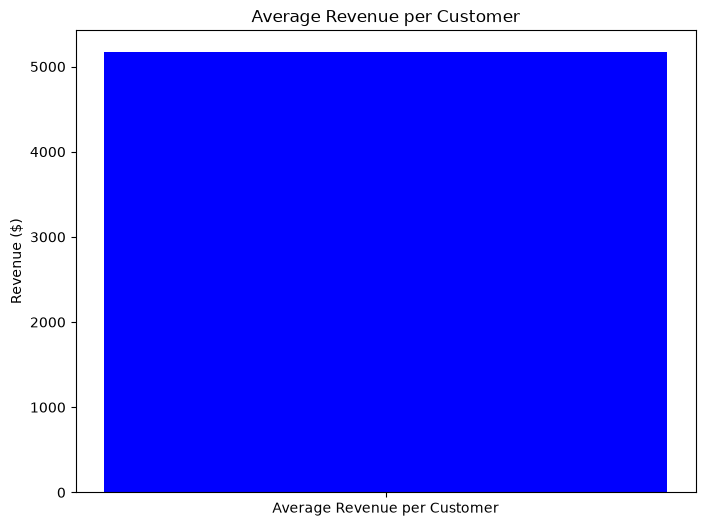

In [55]:
#I want to estimate the total revenue a single customer generates on average. I will do this by dividing the total revenue by the total number of unique customers.
total_revenue = ecomm_data["revenue"].sum()
unique_customers = ecomm_data["customer_id"].nunique()
average_revenue_per_customer = total_revenue / unique_customers
print(average_revenue_per_customer)
#Visulise my findings
plt.figure(figsize=(8, 6))
plt.bar(["Average Revenue per Customer"], [average_revenue_per_customer], color='blue')
plt.title("Average Revenue per Customer")
plt.ylabel("Revenue ($)")